# Mixture of Mixture of Gaussians Example

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from copy import copy
from sklearn.preprocessing import KernelCenterer

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex

ModuleNotFoundError: No module named 'numpy'

# Set Parameters

In [ ]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


noise_sd = 1

# Generate Data

In [ ]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(-3,3,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

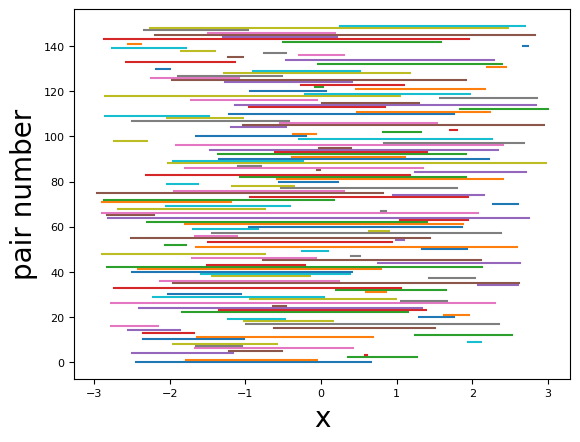

In [ ]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

# Linear

In [ ]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = 5*X[component_ids==0] -4
Y[(component_ids==1)] = -2*X[component_ids==1] + 5
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

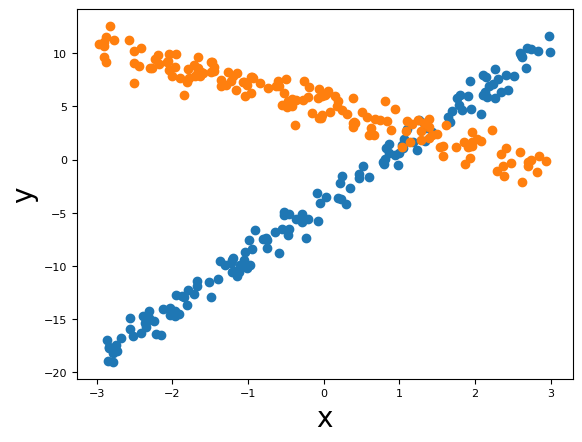

In [ ]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
plt.xlabel("x")
plt.ylabel("y")
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=8)    # fontsize of the tick labels
plt.rc('ytick', labelsize=8)    # fontsize of the tick labels
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

Text(0.5, 0, 'x')

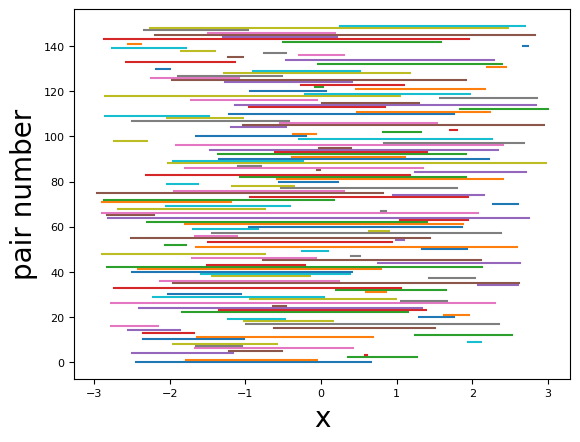

In [ ]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Nonlinear

In [ ]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = X[component_ids==0]**2 + 3
Y[(component_ids==1)] = -X[component_ids==1]**2 - 3

Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

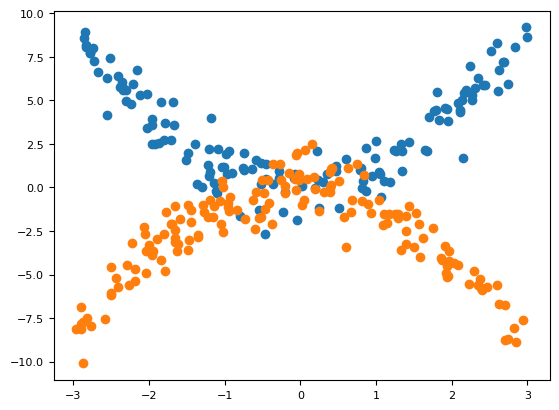

In [ ]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [ ]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [ ]:
kern_width = .8

K = gauss_kernal_mat(X,X,sigma=kern_width)
# transformer = KernelCentere
#r().fit(K)
# K = transformer.transform(K)
w, A = scipy.sparse.linalg.eigs(K, k=M)
w = np.real(w)
A = np.real(A)
w = w/np.sum(w)
maxiter = 30

R = np.zeros((n,M))

K = np.asarray(K, dtype=np.float64)
K = 0.5 * (K + K.T)

y = np.asarray(Y, dtype=np.float64).reshape(-1)
coef = np.asarray(A, dtype=np.float64).copy()
pi = np.asarray(w, dtype=np.float64).reshape(-1).copy()

N = K.shape[0]
M = coef.shape[1]

assert K.shape == (N, N)
assert y.shape == (N,)
assert coef.shape == (N, M)
assert pi.shape == (M,)
assert N % 2 == 0

n_pairs = N // 2
lam = 1e-8

from scipy.linalg import cho_factor, cho_solve
from scipy.special import logsumexp

for iteration in range(maxiter):

    # ----------------
    # E-step
    # ----------------
    Yv = np.asarray(Y).reshape(-1)  # shape: (300,)
    Mu = K @ A                      # shape: (300, M)

    Delta = (Yv[:, None] - Mu)**2   # shape: (300, M)

    n2 = Yv.size
    n_pairs = n2 // 2

    # Group adjacent observations, then sum within each pair
    pair_residual_sum = Delta.reshape(n_pairs, 2, M).sum(axis=1)
    # shape: (150, M)

    log_pair = (
        np.log(np.asarray(w).reshape(1, M))
        - pair_residual_sum / (2 * noise_sd**2)
    )

    # Stable softmax across components, R has shape (n_pairs, M)
    R = np.exp(
        log_pair -
        logsumexp(log_pair, axis=1, keepdims=True)
    )
    
    ### for new way
    # fitted = K @ coef
    # residual_sq = (y[:, None] - fitted)**2

    # pair_residual_sq = (
    #     residual_sq[0::2, :] +
    #     residual_sq[1::2, :]
    # )

    # log_scores = (
    #     np.log(np.maximum(pi, 1e-15))[None, :]
    #     - pair_residual_sq / (2.0 * noise_sd**2)
    # )

    # log_R = log_scores - logsumexp(
    #     log_scores,
    #     axis=1,
    #     keepdims=True
    # )
    # R = np.exp(log_R)

    
    
####### M-step
    w = np.sum(R,axis=0) / n

    # ----------------
    # M-step
    # ----------------

    # without penalty: new method
    for j in range(M):
        Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        A[:,j] = lstsq_nesterov((K.T*Rm ).T, (Y.T*Rm).T, A[:,j]) # correct way
        #print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))


##    with penalty: new method
#     pi = R.mean(axis=0)

#     coef_new = np.empty_like(coef)

#     for j in range(M):
#         Rm = np.repeat(R[:, j], 2).reshape(-1)
#         s = np.sqrt(np.maximum(Rm, 0.0))

#         B = (s[:, None] * K) * s[None, :]
#         B = 0.5 * (B + B.T)

#         system = B + lam * np.eye(N)
#         rhs = s * y

#         factor = cho_factor(
#             system,
#             lower=True,
#             check_finite=True
#         )
#         gamma = cho_solve(
#             factor,
#             rhs,
#             check_finite=True
#         )

#         coef_new[:, j] = s * gamma

#     # Optional convergence check
#     difference = np.linalg.norm(coef_new - coef)
#     coef = coef_new

#     if not np.isfinite(coef).all():
#         raise FloatingPointError(
#             f"Nonfinite coefficient at iteration {iteration}"
#         )

#     if difference < 1e-8:
#         break

# A = coef
# w = pi




# #### old method
# for i in range(maxiter):
#     print(i)
#     # E-step
#     Delta = (Y - K@A)**2 #square loss for each observation for each component
#     print(K@A)
#     #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
#     Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
#     R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
    
#     # M-step
#     w = np.sum(R,axis=0) / n
#     for j in range(M):
#         ### without penalty
#         # Rm = np.repeat(R[:,j]**0.5,2,axis=0)
#         # A[:,j] = lstsq_nesterov((K.T*Rm ).T, (Y.T*Rm).T, A[:,j]) # correct way
        
#         # #A[:,j] = np.linalg.inv(np.diag(Rm) @ K + lam*np.eye(len(Rm))) @ np.diag(Rm) @ Y
#         # #A[:,j] = np.linalg.lstsq((K.T*Rm).T, (Y.T*Rm).T, rcond=None)[0].flatten()
#         # print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))
        
#         ### with penalty
#         Rm = np.repeat(R[:, j], 2)

#         lam = 1e-4

#         W_K = Rm[:, None] * K
#         W_Y = Rm * Y.squeeze()

#         A[:, j] = np.linalg.solve(
#             W_K + lam * np.eye(K.shape[0]),
#             W_Y
#         )

In [ ]:
Rprime = copy(R)
Rprime[R<0.01] = 0
Rprime[R>0.99] = 1
print(Rprime)

[[1.         0.        ]
 [0.         1.        ]
 [0.84271907 0.15728093]
 [1.         0.        ]
 [1.         0.        ]
 [0.21755301 0.78244699]
 [1.         0.        ]
 [1.         0.        ]
 [0.         1.        ]
 [1.         0.        ]
 [0.         1.        ]
 [1.         0.        ]
 [1.         0.        ]
 [0.         1.        ]
 [0.         1.        ]
 [0.         1.        ]
 [0.         1.        ]
 [1.         0.        ]
 [0.38563891 0.61436109]
 [0.91692157 0.08307843]
 [0.         1.        ]
 [0.         1.        ]
 [1.         0.        ]
 [0.96708269 0.03291731]
 [1.         0.        ]
 [0.92888638 0.07111362]
 [0.         1.        ]
 [1.         0.        ]
 [0.01117518 0.98882482]
 [1.         0.        ]
 [0.         1.        ]
 [0.         1.        ]
 [1.         0.        ]
 [0.         1.        ]
 [1.         0.        ]
 [1.         0.        ]
 [0.         1.        ]
 [0.         1.        ]
 [0.95590703 0.04409297]
 [1.         0.        ]


# Check out the results

In [ ]:
Y_hat = np.zeros((2*n,M))
for j in range(M):
        #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
        Y_hat[:,j] = K@A[:,j]

Prop Correct Mixture Assignment = 0.56


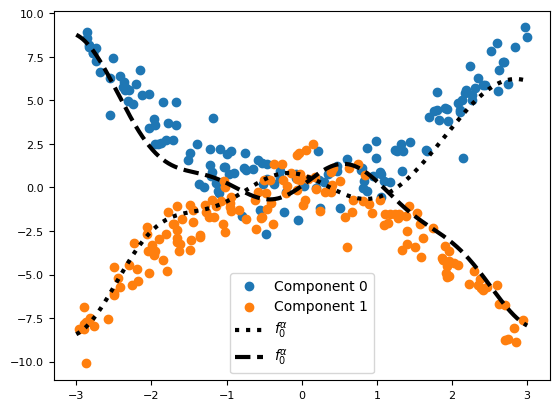

In [ ]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(-3,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)
correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
                          sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
                         ) / (2*n)
print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

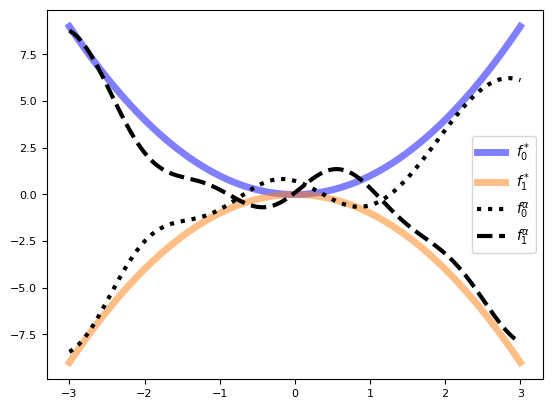

In [ ]:
plt.plot(xx, xx**2, 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, -xx**2, 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5)
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


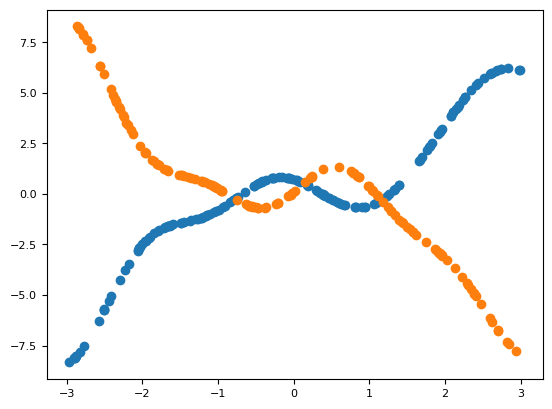

In [ ]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Y_hat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Y_hat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

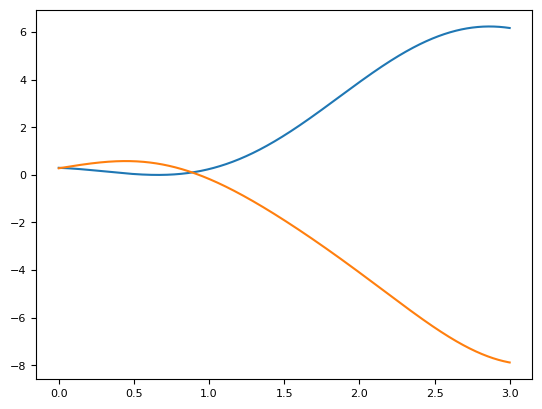

In [ ]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])